# Deteksi Kendaraan Melawan Arah & Pembacaan Plat Nomor


In [1]:
# Import library
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt
import easyocr
import re
import numpy as np
import logging

In [2]:
# Path model
model_arah_path = 'C:/Users/salsa/OneDrive/Documents/comvis & pp/model/model-arah-kendaraan.pt'
model_plat_path = 'C:/Users/salsa/OneDrive/Documents/comvis & pp/model/model-plat-nomor.pt'

# Load model
model_arah = YOLO(model_arah_path)
model_plat = YOLO(model_plat_path)

# Inisialisasi EasyOCR
reader = easyocr.Reader(['en'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [3]:
# Folder gambar/video uji
uji_folder = 'C:/Users/salsa/OneDrive/Documents/comvis & pp/data uji'
img_files = [f for f in os.listdir(uji_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

In [ ]:
def optimize_bbox_for_ocr(img_shape, x1, y1, x2, y2, margin_ratio=0.15):
    """
    Optimalisasi bounding box dengan menambahkan margin untuk OCR yang lebih baik
    """
    h, w = img_shape[:2]
    
    # Hitung margin berdasarkan ukuran bounding box
    bbox_width = x2 - x1
    bbox_height = y2 - y1
    margin_x = int(bbox_width * margin_ratio)
    margin_y = int(bbox_height * margin_ratio)
    
    # Tambahkan margin dengan memastikan tidak keluar dari batas gambar
    x1_opt = max(0, x1 - margin_x)
    y1_opt = max(0, y1 - margin_y)
    x2_opt = min(w, x2 + margin_x)
    y2_opt = min(h, y2 + margin_y)
    
    return x1_opt, y1_opt, x2_opt, y2_opt

def preprocess_plat_image(img):
    # img: numpy array (RGB atau grayscale)
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img
    
    # Resize jika plat terlalu kecil
    h, w = img_gray.shape
    min_height, min_width = 60, 180 
    if h < min_height or w < min_width:
        scale_factor = max(min_height/h, min_width/w)
        new_h, new_w = int(h * scale_factor), int(w * scale_factor)
        img_gray = cv2.resize(img_gray, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    
    mean_intensity = np.mean(img_gray)
    is_dark_background = mean_intensity < 128
    
    if is_dark_background:
        img_proc = cv2.bitwise_not(img_gray)
        img_proc = cv2.fastNlMeansDenoising(img_proc, h=10)
    else:
        img_proc = cv2.fastNlMeansDenoising(img_gray, h=10)
        img_proc = cv2.equalizeHist(img_proc)
    
    # Sharpening untuk meningkatkan ketajaman
    kernel_sharpen = np.array([[-1,-1,-1], 
                               [-1, 9,-1], 
                               [-1,-1,-1]])
    img_proc = cv2.filter2D(img_proc, -1, kernel_sharpen)
    
    return img_proc

def bersihkan_teks(teks, parts):
    # Normalisasi karakter mirip
    teks_orig = teks
    teks = re.sub(r'[Oo0Ii][Dd0][Dd0]?|[Dd][Dd0][Dd0]?', 'DD', teks, flags=re.IGNORECASE)
    teks = re.sub(r'[Dd][Ww]|[0Oo][Ww]', 'DW', teks, flags=re.IGNORECASE)
    teks = re.sub(r'[Dd][Pp][\s]?|[0Oo][Pp][\s]?', 'DP', teks, flags=re.IGNORECASE)

    # Hapus karakter non-alfanumerik dan normalisasi spasi
    teks = re.sub(r'[^A-Za-z0-9\s]', '', teks)
    teks = ' '.join(teks.split())

    # Coba ekstraksi langsung dari teks bersih
    components = re.findall(r'([A-Za-z]{1,3})\s*(\d{3,5})\s*([A-Za-z]{1,3})', teks, flags=re.IGNORECASE)
    if components:
        code, num, letters = components[0]
        code = code.upper()
        if code not in ['DD', 'DW']:
            code = 'DP'
        num = num[:4] if len(num) >= 4 else num.ljust(4, '0')
        letters = letters[:3].upper()
        if len(letters) >= 2:
            return f"{code} {num} {letters}"

    # Fallback: per-part analysis (parts = list of OCR token strings)
    code = None
    numbers = None
    letters = None
    for part in parts:
        part_clean = re.sub(r'[^A-Za-z0-9]', '', part).upper()
        if re.match(r'^(DD|DW|DP)$', part_clean):
            if part_clean.startswith('DD'):
                code = 'DD'
            elif part_clean.startswith('DW'):
                code = 'DW'
            else:
                code = 'DP'
        if re.search(r'\d{3,5}', part):
            numbers = re.search(r'\d{3,5}', part).group(0)[:4]
        if re.match(r'^[A-Z]{2,4}$', part_clean):
            letters = part_clean[:3]

    if code and numbers and letters:
        numbers = numbers.ljust(4, '0') if len(numbers) < 4 else numbers[:4]
        return f"{code} {numbers} {letters}"

    # Jika semua gagal, kembalikan teks asli (mentah)
    return teks_orig

def validasi_plat_nomor(teks):
    pola = r'^(DD|DW|DP\s?) \d{4} [A-Z]{2,3}$'
    return bool(re.match(pola, teks))

def baca_plat_nomor(plat_crop, reader):
    # plat_crop: numpy array (RGB)
    if plat_crop.size == 0:
        return '', False

    img_proc = preprocess_plat_image(plat_crop)
    results = []

    # Multi-attempt dengan preprocessing berbeda
    img_attempts = [
        img_proc,  # Preprocessed
        cv2.cvtColor(plat_crop, cv2.COLOR_RGB2GRAY),  
    ]

    # Parameter OCR yang berbeda untuk setiap attempt
    ocr_configs = [
        {'width_ths': 0.5, 'mag_ratio': 2.0, 'contrast_ths': 0.2},  # Default
        {'width_ths': 0.3, 'mag_ratio': 2.5, 'contrast_ths': 0.1},  # Lebih agresif
    ]

    for attempt_idx, img in enumerate(img_attempts, 1):
        for cfg_idx, config in enumerate(ocr_configs, 1):
            try:
                ocr_result = reader.readtext(
                    img, 
                    allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 ',
                    detail=1,
                    **config
                )
                # Debug prints untuk melacak keluaran OCR
                print(f"[OCR DEBUG] attempt={attempt_idx}, cfg={cfg_idx}, ocr_result={ocr_result}")

                teks_plat_mentah = [item[1] for item in ocr_result]
                teks_gabungan = ' '.join(teks_plat_mentah)
                teks_bersih = bersihkan_teks(teks_gabungan, teks_plat_mentah)

                print(f"[OCR DEBUG] teks_gabungan='{teks_gabungan}' -> teks_bersih='{teks_bersih}' (valid={validasi_plat_nomor(teks_bersih)})")

                if validasi_plat_nomor(teks_bersih):
                    return teks_bersih, True

                results.append((teks_bersih, teks_plat_mentah))
            except Exception as e:
                print(f"[OCR ERROR] attempt={attempt_idx}, cfg={cfg_idx}, error={e}")
                continue

    # Fallback: tampilkan hasil percobaan untuk debugging lalu return best attempt
    if results:
        print(f"[OCR DEBUG] fallback results={results}")
        return results[0][0], False
    print("[OCR DEBUG] no results from OCR attempts")
    return '', False


0: 384x640 2 correct_vehicle_directions, 1 opposite_vehicle_direction, 3368.9ms
Speed: 62.3ms preprocess, 3368.9ms inference, 30.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 plat-nomors, 1116.6ms
Speed: 5.5ms preprocess, 1116.6ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

=== Harsh Lighting (1).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 581,52,891,1079


c:\Users\salsa\OneDrive\Documents\comvis & pp\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(35), np.int32(17)], [np.int32(212), np.int32(17)], [np.int32(212), np.int32(56)], [np.int32(35), np.int32(56)]], 'DD 3623  TC', np.float64(0.6356739589383186)), ([[np.int32(128), np.int32(55)], [np.int32(210), np.int32(55)], [np.int32(210), np.int32(81)], [np.int32(128), np.int32(81)]], '0826', np.float64(0.18321442604064941))]
[OCR DEBUG] teks_gabungan='DD 3623  TC 0826' -> teks_bersih='DD 3623 TC' (valid=True)
Valid Plate (Wrong-Way Vehicle): DD 3623 TC
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(35), np.int32(17)], [np.int32(212), np.int32(17)], [np.int32(212), np.int32(56)], [np.int32(35), np.int32(56)]], 'DD 3623  TC', np.float64(0.6356739589383186)), ([[np.int32(128), np.int32(55)], [np.int32(210), np.int32(55)], [np.int32(210), np.int32(81)], [np.int32(128), np.int32(81)]], '0826', np.float64(0.18321442604064941))]
[OCR DEBUG] teks_gabungan='DD 3623  TC 0826' -> teks_bersih='DD 3623 TC' (valid=True)


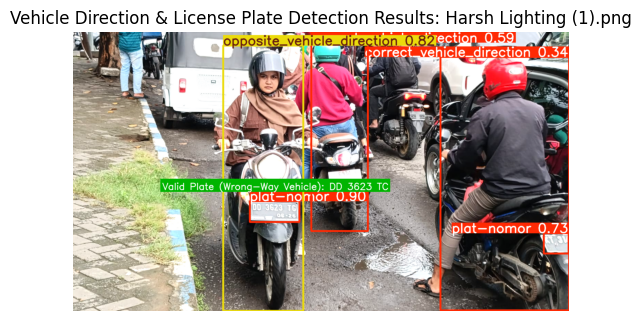


0: 384x640 3 correct_vehicle_directions, 1 opposite_vehicle_direction, 2266.3ms
Speed: 10.8ms preprocess, 2266.3ms inference, 50.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 plat-nomors, 673.5ms
Speed: 3.9ms preprocess, 673.5ms inference, 7.8ms postprocess per image at shape (1, 3, 384, 640)

=== Harsh Lighting (2).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 933,215,1238,906
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(56), np.int32(11)], [np.int32(150), np.int32(11)], [np.int32(150), np.int32(31)], [np.int32(56), np.int32(31)]], '3987 XCS', np.float64(0.48499390716712826)), ([[np.int32(95), np.int32(32)], [np.int32(149), np.int32(32)], [np.int32(149), np.int32(45)], [np.int32(95), np.int32(45)]], '08423', np.float64(0.46912755081876406))]
[OCR DEBUG] teks_gabungan='3987 XCS 08423' -> teks_bersih='3987 XCS 08423' (valid=False)
[OCR DEBUG] attempt=1, cfg=2, ocr_result=[([[np.int32(55), np.int32(10)], [np.int32(150), 

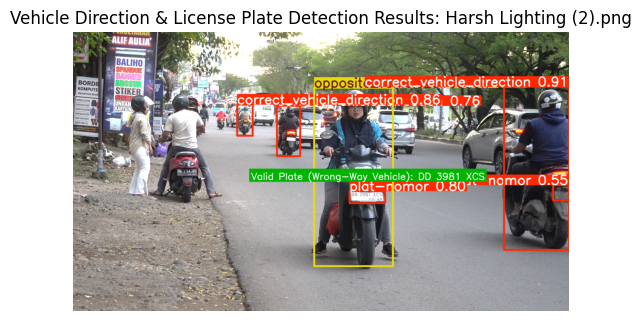


0: 384x640 2 correct_vehicle_directions, 2 opposite_vehicle_directions, 2232.5ms
Speed: 5.9ms preprocess, 2232.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 plat-nomor, 667.8ms
Speed: 5.1ms preprocess, 667.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

=== Harsh Lighting (3).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 602,354,812,913
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[]
[OCR DEBUG] teks_gabungan='' -> teks_bersih='' (valid=False)
[OCR DEBUG] attempt=1, cfg=2, ocr_result=[]
[OCR DEBUG] teks_gabungan='' -> teks_bersih='' (valid=False)
[OCR DEBUG] attempt=2, cfg=1, ocr_result=[([[np.int32(18), np.int32(9)], [np.int32(103), np.int32(9)], [np.int32(103), np.int32(25)], [np.int32(18), np.int32(25)]], 'DD 2617 QA', np.float64(0.9652840286911797))]
[OCR DEBUG] teks_gabungan='DD 2617 QA' -> teks_bersih='DD 2617 QA' (valid=True)
Valid Plate (Wrong-Way Vehicle): DD 2617 QA
Vehicle2
Wrong-Wa

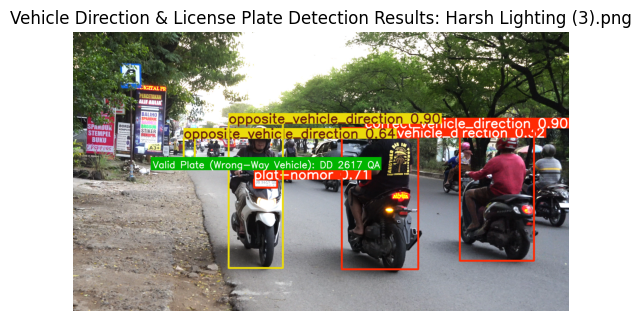


0: 384x640 3 correct_vehicle_directions, 2 opposite_vehicle_directions, 5820.1ms
Speed: 70.8ms preprocess, 5820.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 plat-nomor, 902.7ms
Speed: 4.5ms preprocess, 902.7ms inference, 4.8ms postprocess per image at shape (1, 3, 384, 640)

=== Harsh Lighting (4).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 497,115,859,956
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(126), np.int32(14)], [np.int32(152), np.int32(14)], [np.int32(152), np.int32(28)], [np.int32(126), np.int32(28)]], 'TC', np.float64(0.22388295022874133))]
[OCR DEBUG] teks_gabungan='TC' -> teks_bersih='TC' (valid=False)
[OCR DEBUG] attempt=1, cfg=2, ocr_result=[([[np.float64(18.292893218813454), np.float64(24.292893218813454)], [np.float64(46.84227140066151), np.float64(21.460946303576634)], [np.float64(48.707106781186546), np.float64(35.707106781186546)], [np.float64(20.15772859933849), np.float64(38.5

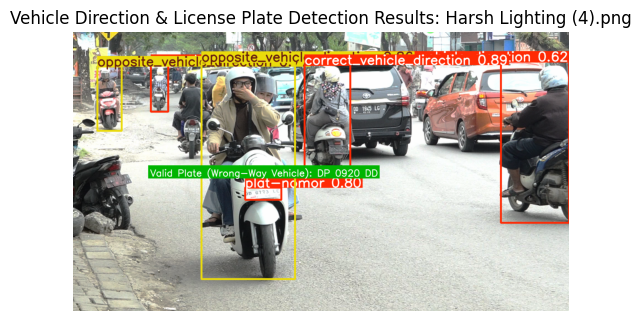


0: 384x640 1 opposite_vehicle_direction, 1661.9ms
Speed: 4.7ms preprocess, 1661.9ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 plat-nomor, 738.8ms
Speed: 3.9ms preprocess, 738.8ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

=== Harsh Lighting (5).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 681,12,1026,1066
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(86), np.int32(23)], [np.int32(157), np.int32(23)], [np.int32(157), np.int32(55)], [np.int32(86), np.int32(55)]], 'C669', np.float64(0.36991411447525024)), ([[np.int32(168), np.int32(30)], [np.int32(206), np.int32(30)], [np.int32(206), np.int32(57)], [np.int32(168), np.int32(57)]], 'Z0', np.float64(0.9710996911196628))]
[OCR DEBUG] teks_gabungan='C669 Z0' -> teks_bersih='C669 Z0' (valid=False)
[OCR DEBUG] attempt=1, cfg=2, ocr_result=[([[np.int32(85), np.int32(22)], [np.int32(157), np.int32(22)], [np.int32(157), np.int32(54)], [np.int

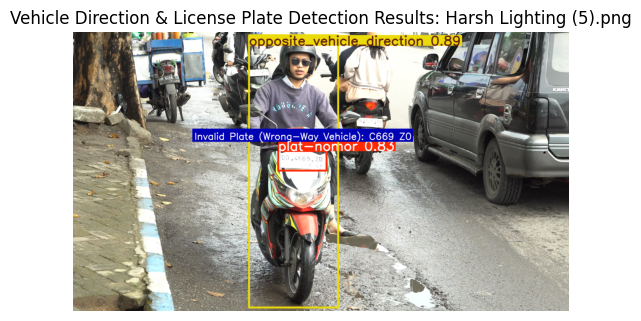


0: 352x640 1 correct_vehicle_direction, 1 opposite_vehicle_direction, 1865.5ms
Speed: 3.0ms preprocess, 1865.5ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)

0: 352x640 1 plat-nomor, 455.6ms
Speed: 4.0ms preprocess, 455.6ms inference, 1.8ms postprocess per image at shape (1, 3, 352, 640)

=== Low Light (1).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 620,190,936,792
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(113), np.int32(9)], [np.int32(142), np.int32(9)], [np.int32(142), np.int32(33)], [np.int32(113), np.int32(33)]], '00', np.float64(0.9374092876087581)), ([[np.int32(27), np.int32(28)], [np.int32(56), np.int32(28)], [np.int32(56), np.int32(52)], [np.int32(27), np.int32(52)]], '00', np.float64(0.42056654854490183)), ([[np.int32(126), np.int32(31)], [np.int32(150), np.int32(31)], [np.int32(150), np.int32(47)], [np.int32(126), np.int32(47)]], '4', np.float64(0.29769321058041953)), ([[np.float64(57.58578643762691), n

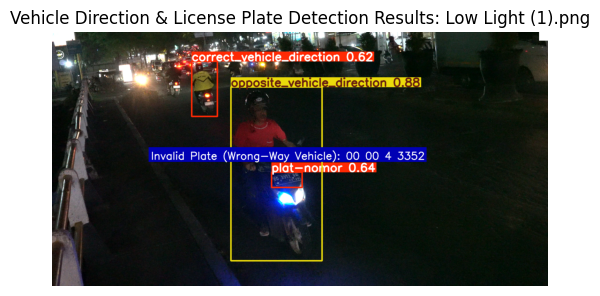


0: 384x640 2 opposite_vehicle_directions, 1479.6ms
Speed: 20.0ms preprocess, 1479.6ms inference, 9.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 plat-nomors, 542.1ms
Speed: 14.9ms preprocess, 542.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

=== Low Light (2).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 70,0,224,318
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[]
[OCR DEBUG] teks_gabungan='' -> teks_bersih='' (valid=False)
[OCR DEBUG] attempt=1, cfg=2, ocr_result=[]
[OCR DEBUG] teks_gabungan='' -> teks_bersih='' (valid=False)
[OCR DEBUG] attempt=2, cfg=1, ocr_result=[]
[OCR DEBUG] teks_gabungan='' -> teks_bersih='' (valid=False)
[OCR DEBUG] attempt=2, cfg=2, ocr_result=[]
[OCR DEBUG] teks_gabungan='' -> teks_bersih='' (valid=False)
[OCR DEBUG] fallback results=[('', []), ('', []), ('', []), ('', [])]
Invalid Plate (Wrong-Way Vehicle): 
Vehicle2
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the 

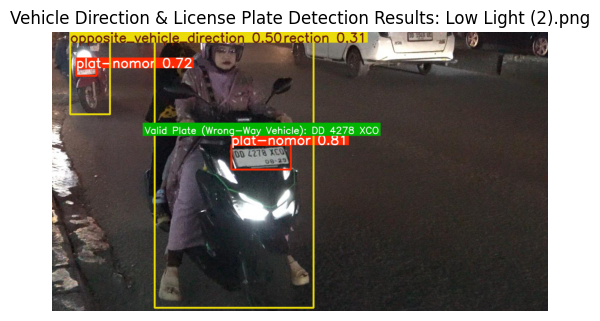


0: 384x640 1 opposite_vehicle_direction, 2024.5ms
Speed: 17.5ms preprocess, 2024.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 plat-nomor, 425.5ms
Speed: 3.4ms preprocess, 425.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

=== Low Light (3).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 724,325,1093,1065
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(24), np.int32(20)], [np.int32(106), np.int32(20)], [np.int32(106), np.int32(56)], [np.int32(24), np.int32(56)]], 'IDLS87', np.float64(0.2979270369914676)), ([[np.float64(96.41000317999045), np.float64(19.456005087984735)], [np.float64(144.49615088301354), np.float64(14.335899411324313)], [np.float64(146.58999682000953), np.float64(40.543994912015265)], [np.float64(97.50384911698647), np.float64(45.66410058867569)]], '41B', np.float64(0.17579529677410524))]
[OCR DEBUG] teks_gabungan='IDLS87 41B' -> teks_bersih='IDLS87 41B' (valid=False)


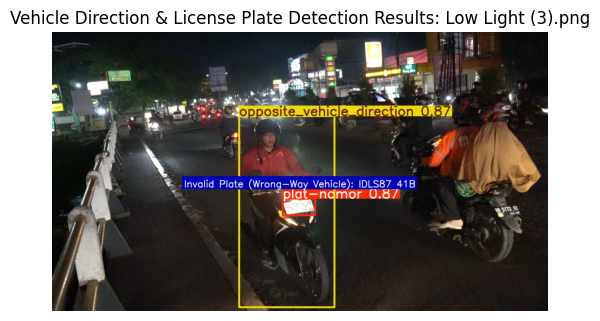


0: 384x640 (no detections), 1965.4ms
Speed: 14.7ms preprocess, 1965.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 plat-nomor, 666.3ms
Speed: 4.6ms preprocess, 666.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

=== Low Light (4).png ===
No wrong-way vehicle detected. Process all plates in the image.
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(63), np.int32(16)], [np.int32(157), np.int32(16)], [np.int32(157), np.int32(61)], [np.int32(63), np.int32(61)]], '6176 D0', np.float64(0.26918299945028423)), ([[np.int32(28), np.int32(36)], [np.int32(64), np.int32(36)], [np.int32(64), np.int32(67)], [np.int32(28), np.int32(67)]], 'DD', np.float64(0.4341765723104813))]
[OCR DEBUG] teks_gabungan='6176 D0 DD' -> teks_bersih='DD 6176 DD' (valid=True)
Valid Plate: DD 6176 DD
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(63), np.int32(16)], [np.int32(157), np.int32(16)], [np.int32(157), np.int32(61)], [np.int32(63), np.int32(6

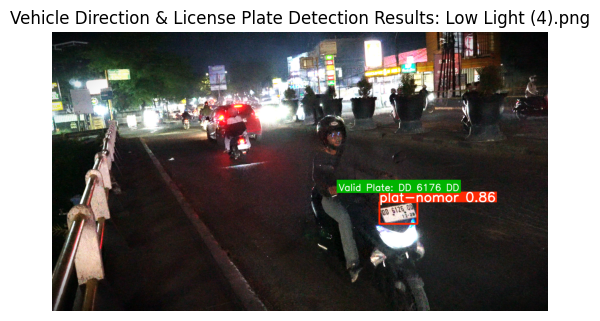


0: 384x640 1 correct_vehicle_direction, 1 opposite_vehicle_direction, 2194.7ms
Speed: 20.4ms preprocess, 2194.7ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 plat-nomor, 537.1ms
Speed: 4.5ms preprocess, 537.1ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

=== Low Light (5).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 797,314,1199,1047
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(109), np.int32(11)], [np.int32(144), np.int32(11)], [np.int32(144), np.int32(36)], [np.int32(109), np.int32(36)]], 'LA', np.float64(0.5781456278344438)), ([[np.int32(21), np.int32(34)], [np.int32(62), np.int32(34)], [np.int32(62), np.int32(54)], [np.int32(21), np.int32(54)]], 'DO ', np.float64(0.1880928229408091)), ([[np.float64(54.654654412007375), np.float64(26.52011985320811)], [np.float64(119.79489738994859), np.float64(18.11776229985578)], [np.float64(122.34534558799263), np.float64(40.479880146791885)]

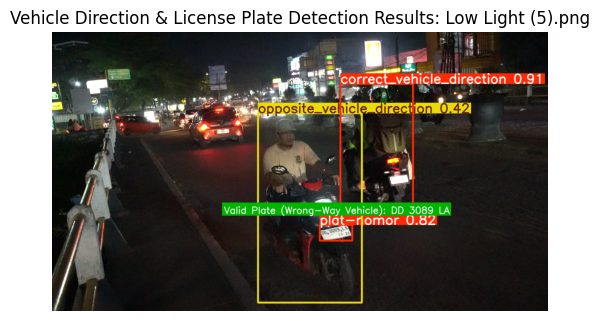


0: 352x640 2 correct_vehicle_directions, 1 opposite_vehicle_direction, 3972.4ms
Speed: 7.5ms preprocess, 3972.4ms inference, 4.4ms postprocess per image at shape (1, 3, 352, 640)

0: 352x640 1 plat-nomor, 794.5ms
Speed: 7.4ms preprocess, 794.5ms inference, 5.5ms postprocess per image at shape (1, 3, 352, 640)

=== Normal Lighting (1).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 503,56,787,772
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(18), np.int32(15)], [np.int32(153), np.int32(15)], [np.int32(153), np.int32(41)], [np.int32(18), np.int32(41)]], 'DW 6725 FD', np.float64(0.5907368029976549)), ([[np.int32(96), np.int32(42)], [np.int32(120), np.int32(42)], [np.int32(120), np.int32(54)], [np.int32(96), np.int32(54)]], 'O1', np.float64(0.3199816387129934))]
[OCR DEBUG] teks_gabungan='DW 6725 FD O1' -> teks_bersih='DW 6725 FD' (valid=True)
Valid Plate (Wrong-Way Vehicle): DW 6725 FD
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(18), 

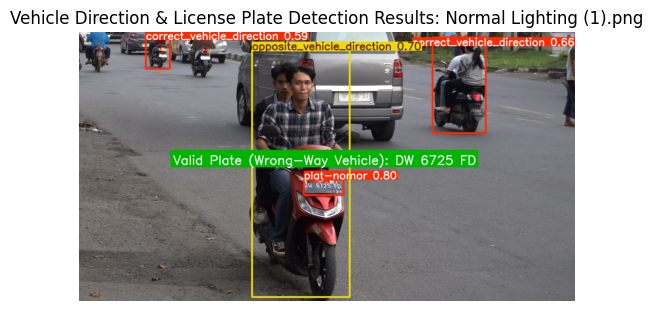


0: 384x640 3 correct_vehicle_directions, 1 opposite_vehicle_direction, 3075.7ms
Speed: 6.4ms preprocess, 3075.7ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 plat-nomor, 593.1ms
Speed: 4.4ms preprocess, 593.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

=== Normal Lighting (2).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 866,117,1174,815
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(27), np.int32(12)], [np.int32(163), np.int32(12)], [np.int32(163), np.int32(53)], [np.int32(27), np.int32(53)]], 'DD 4162 BW', np.float64(0.3880102746252635)), ([[np.float64(103.65465441200737), np.float64(46.520119853208115)], [np.float64(163.86150298688068), np.float64(42.268695255154014)], [np.float64(164.34534558799263), np.float64(60.479880146791885)], [np.float64(104.1384970131193), np.float64(65.73130474484599)]], '0L 26', np.float64(0.5467689524602212))]
[OCR DEBUG] teks_gabungan='DD 4162 BW 0L 

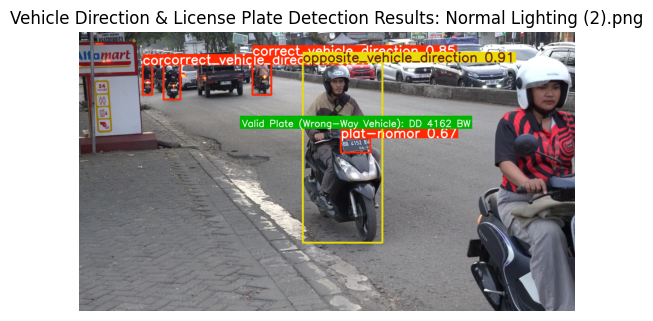


0: 384x640 2 correct_vehicle_directions, 1 opposite_vehicle_direction, 3077.5ms
Speed: 4.7ms preprocess, 3077.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 plat-nomor, 586.0ms
Speed: 13.2ms preprocess, 586.0ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

=== Normal Lighting (3).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 117,53,325,541
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(22), np.int32(13)], [np.int32(153), np.int32(13)], [np.int32(153), np.int32(49)], [np.int32(22), np.int32(49)]], 'DO 5370 LB', np.float64(0.11921962567487758)), ([[np.int32(98), np.int32(41)], [np.int32(153), np.int32(41)], [np.int32(153), np.int32(57)], [np.int32(98), np.int32(57)]], '10 26', np.float64(0.3936352163518186))]
[OCR DEBUG] teks_gabungan='DO 5370 LB 10 26' -> teks_bersih='DP 5370 LB' (valid=True)
Valid Plate (Wrong-Way Vehicle): DP 5370 LB
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int

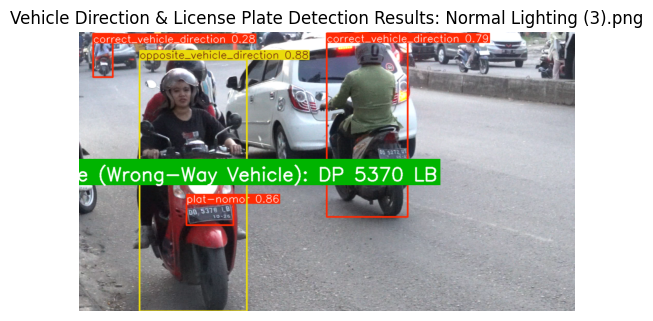


0: 352x640 1 opposite_vehicle_direction, 3054.3ms
Speed: 13.7ms preprocess, 3054.3ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)

0: 352x640 1 plat-nomor, 601.0ms
Speed: 3.1ms preprocess, 601.0ms inference, 1.5ms postprocess per image at shape (1, 3, 352, 640)

=== Normal Lighting (4).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 324,20,567,674
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(22), np.int32(14)], [np.int32(154), np.int32(14)], [np.int32(154), np.int32(44)], [np.int32(22), np.int32(44)]], 'DD 5908 4LC', np.float64(0.6289936233624082)), ([[np.int32(94), np.int32(37)], [np.int32(153), np.int32(37)], [np.int32(153), np.int32(55)], [np.int32(94), np.int32(55)]], '00 28', np.float64(0.3396929617874594))]
[OCR DEBUG] teks_gabungan='DD 5908 4LC 00 28' -> teks_bersih='DD 5908 4LC 00 28' (valid=False)
[OCR DEBUG] attempt=1, cfg=2, ocr_result=[([[np.int32(22), np.int32(12)], [np.int32(116), np.int32(12)], [np.int32(1

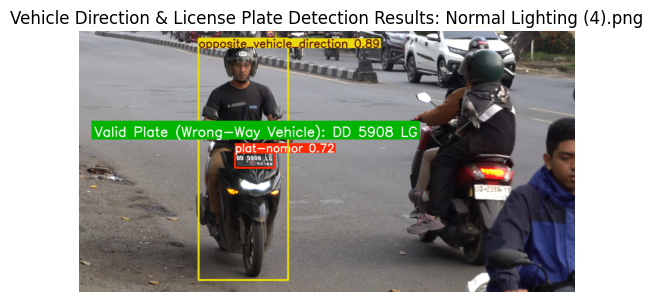


0: 384x640 1 opposite_vehicle_direction, 3262.6ms
Speed: 14.3ms preprocess, 3262.6ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 plat-nomor, 638.2ms
Speed: 3.7ms preprocess, 638.2ms inference, 8.3ms postprocess per image at shape (1, 3, 384, 640)

=== Normal Lighting (5).png ===
Vehicle1
Wrong-Way Vehicle Detection: opposite_vehicle_direction On the box 196,44,489,678
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(25), np.int32(11)], [np.int32(147), np.int32(11)], [np.int32(147), np.int32(39)], [np.int32(25), np.int32(39)]], 'IDP   2956 SF', np.float64(0.62229644641588)), ([[np.int32(93), np.int32(38)], [np.int32(148), np.int32(38)], [np.int32(148), np.int32(54)], [np.int32(93), np.int32(54)]], '00   3 7', np.float64(0.2009653170299332))]
[OCR DEBUG] teks_gabungan='IDP   2956 SF 00   3 7' -> teks_bersih='DP 2956 SF' (valid=True)
Valid Plate (Wrong-Way Vehicle): DP 2956 SF
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(25), np.int32(11)]

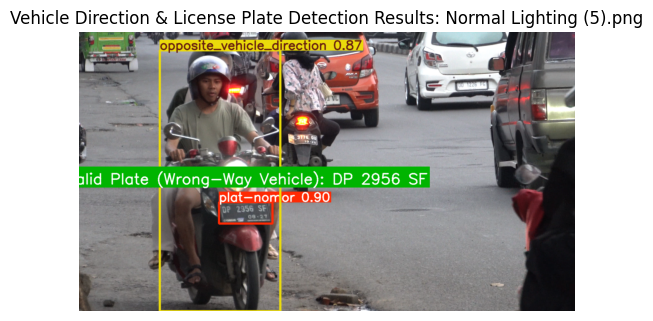

In [ ]:
# Pola plat nomor Sulawesi Selatan: DD 1234 XX
plat_pattern = re.compile(r'^(DD|DW|DP\s?) \d{4} [A-Z]{2,3}$')

valid_plates = []

for img_name in img_files:
    img_path = os.path.join(uji_folder, img_name)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Deteksi arah kendaraan
    results_arah = model_arah.predict(source=img_rgb, conf=0.25, save=False)
    arah_boxes = results_arah[0].boxes.xyxy.cpu().numpy() if results_arah[0].boxes is not None else []
    arah_classes = results_arah[0].boxes.cls.cpu().numpy() if results_arah[0].boxes is not None else []
    arah_names = results_arah[0].names if hasattr(results_arah[0], 'names') else {}

    # Deteksi plat nomor dengan confidence threshold lebih tinggi
    results_plat = model_plat.predict(source=img_rgb, conf=0.35, save=False)
    plat_boxes = results_plat[0].boxes.xyxy.cpu().numpy() if results_plat[0].boxes is not None else []

    print(f'\n=== {img_name} ===')

    # Deteksi kendaraan melawan arah 
    melawan_arah_indices = [i for i, cls in enumerate(arah_classes) if (arah_names[int(cls)].lower() == 'opposite_vehicle_direction' or int(cls) == 1)]

    if len(melawan_arah_indices) > 0:
        for idx_num, idx in enumerate(melawan_arah_indices, 1):
            box_kend = arah_boxes[idx]
            xk1, yk1, xk2, yk2 = map(int, box_kend)
            label = arah_names[int(arah_classes[idx])] if int(arah_classes[idx]) in arah_names else str(int(arah_classes[idx]))
            print(f"Vehicle{idx_num}")
            print(f"Wrong-Way Vehicle Detection: {label} On the box {xk1},{yk1},{xk2},{yk2}")
            # Cari plat yang berada di dalam bounding box kendaraan
            plat_found = False
            for box in plat_boxes:
                xp1, yp1, xp2, yp2 = map(int, box)
                # Cek apakah plat ada di dalam kendaraan
                if xp1 >= xk1 and yp1 >= yk1 and xp2 <= xk2 and yp2 <= yk2:
                    # Optimalisasi bbox dengan margin
                    xp1_opt, yp1_opt, xp2_opt, yp2_opt = optimize_bbox_for_ocr(
                        img_rgb.shape, xp1, yp1, xp2, yp2, margin_ratio=0.15
                    )
                    plat_crop = img_rgb[yp1_opt:yp2_opt, xp1_opt:xp2_opt]
                    
                    # Validasi ukuran crop
                    if plat_crop.size > 0:
                        plat_text, is_valid = baca_plat_nomor(plat_crop, reader)
                        if is_valid:
                            print(f"Valid Plate (Wrong-Way Vehicle): {plat_text}")
                            valid_plates.append(plat_text)
                        else:
                            print(f"Invalid Plate (Wrong-Way Vehicle): {plat_text}")
                        plat_found = True
            if not plat_found:
                print("No license plate found on this wrong-way vehicle.")
    else:
        print("No wrong-way vehicle detected. Process all plates in the image.")
        for box in plat_boxes:
            x1, y1, x2, y2 = map(int, box)
            # Optimalisasi bbox dengan margin
            x1_opt, y1_opt, x2_opt, y2_opt = optimize_bbox_for_ocr(
                img_rgb.shape, x1, y1, x2, y2, margin_ratio=0.15
            )
            plat_crop = img_rgb[y1_opt:y2_opt, x1_opt:x2_opt]
            
            # Validasi ukuran crop
            if plat_crop.size > 0:
                plat_text, is_valid = baca_plat_nomor(plat_crop, reader)
                if is_valid:
                    print(f"Valid Plate: {plat_text}")
                    valid_plates.append(plat_text)
                else:
                    print(f"Invalid Plate: {plat_text}")

        # Visualisasi hasil deteksi arah dan plat
    img_plot = results_plat[0].plot()
    img_plot = results_arah[0].plot(img=img_plot) if hasattr(results_arah[0], 'plot') else img_plot

    # Tambahkan anotasi status plat pada gambar
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.2
    font_color = (255, 255, 255)      # Putih untuk teks
    bg_color_valid = (0, 180, 0)      # Hijau gelap untuk background valid
    bg_color_invalid = (0, 0, 180)    # Merah gelap untuk background invalid
    thickness = 3.5

    def draw_label_with_bg(img, text, box, is_valid):
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.2
        thickness = 2
        color = (255, 255, 255)  # white text
        bg_color = bg_color_valid if is_valid else bg_color_invalid

        (w, h), baseline = cv2.getTextSize(text, font, font_scale, thickness)
        x1, y1, x2, y2 = box
        center_x = x1 + (x2 - x1) // 2
        text_x = center_x - w // 2
        text_y = max(y1 - 40, 10)

        # Draw rectangle background
        cv2.rectangle(img, (text_x - 4, text_y - h - baseline - 8), (text_x + w + 8, text_y + 4), bg_color, -1)
        # Draw text
        cv2.putText(img, text, (text_x + 4, text_y - 4), font, font_scale, color, thickness, cv2.LINE_AA)

    if len(melawan_arah_indices) > 0:
        for idx in melawan_arah_indices:
            box_kend = arah_boxes[idx]
            xk1, yk1, xk2, yk2 = map(int, box_kend)
            for box in plat_boxes:
                xp1, yp1, xp2, yp2 = map(int, box)
                if xp1 >= xk1 and yp1 >= yk1 and xp2 <= xk2 and yp2 <= yk2:
                    # SOLUSI 1 & 6: Optimalisasi bbox dengan margin
                    xp1_opt, yp1_opt, xp2_opt, yp2_opt = optimize_bbox_for_ocr(
                        img_rgb.shape, xp1, yp1, xp2, yp2, margin_ratio=0.15
                    )
                    plat_crop = img_rgb[yp1_opt:yp2_opt, xp1_opt:xp2_opt]
                    
                    if plat_crop.size > 0:
                        plat_text, is_valid = baca_plat_nomor(plat_crop, reader)
                        if plat_text.strip() != "":
                            label_text = f"{'Valid' if is_valid else 'Invalid'} Plate (Wrong-Way Vehicle): {plat_text}"
                            draw_label_with_bg(img_plot, label_text, (xp1, yp1, xp2, yp2), is_valid)
    else:
        for box in plat_boxes:
            x1, y1, x2, y2 = map(int, box)
            # SOLUSI 1 & 6: Optimalisasi bbox dengan margin
            x1_opt, y1_opt, x2_opt, y2_opt = optimize_bbox_for_ocr(
                img_rgb.shape, x1, y1, x2, y2, margin_ratio=0.15
            )
            plat_crop = img_rgb[y1_opt:y2_opt, x1_opt:x2_opt]
            
            if plat_crop.size > 0:
                plat_text, is_valid = baca_plat_nomor(plat_crop, reader)
                if plat_text.strip() != "":
                    label_text = f"{'Valid' if is_valid else 'Invalid'} Plate: {plat_text}"
                    draw_label_with_bg(img_plot, label_text, (x1, y1, x2, y2), is_valid)

    # Cek channel, jika sudah RGB, tidak perlu konversi lagi
    if img_plot.shape[2] == 3 and np.all(np.array(img_plot[..., 0:3].max(axis=(0, 1))) <= 255):
        plt.imshow(img_plot)
    else:
        img_final_rgb = cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB)
        plt.imshow(img_final_rgb)
    plt.axis('off')
    plt.title(f'Vehicle Direction & License Plate Detection Results: {img_name}')
    plt.show()

In [6]:
# Tampilkan daftar plat nomor valid yang terdeteksi
print('\nList of Valid License Plates:')
for plat in set(valid_plates):
    print(plat)


List of Valid License Plates:
DP 5370 LB
DW 6725 FD
DD 4278 XCO
DD 4162 BW
DD 6176 DD
DD 3623 TC
DP 0920 DD
DD 5908 LG
DP 2956 SF
DD 3089 LA
DD 2617 QA
DD 3981 XCS


In [7]:
output_dir = os.path.join(uji_folder, 'C:\\Users\\salsa\\OneDrive\\Documents\\comvis & pp\\hasil uji')
os.makedirs(output_dir, exist_ok=True)

for img_name in img_files:
    img_path = os.path.join(uji_folder, img_name)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Deteksi ulang untuk mendapatkan hasil plot
    results_arah = model_arah.predict(source=img_rgb, conf=0.25, save=False)
    results_plat = model_plat.predict(source=img_rgb, conf=0.35, save=False)
    img_plot = results_plat[0].plot()
    img_plot = results_arah[0].plot(img=img_plot) if hasattr(results_arah[0], 'plot') else img_plot

    # Ambil bounding box dan class
    arah_boxes = results_arah[0].boxes.xyxy.cpu().numpy() if results_arah[0].boxes is not None else []
    arah_classes = results_arah[0].boxes.cls.cpu().numpy() if results_arah[0].boxes is not None else []
    arah_names = results_arah[0].names if hasattr(results_arah[0], 'names') else {}
    plat_boxes = results_plat[0].boxes.xyxy.cpu().numpy() if results_plat[0].boxes is not None else []

    melawan_arah_indices = [i for i, cls in enumerate(arah_classes) if (arah_names[int(cls)].lower() == 'opposite_vehicle_direction' or int(cls) == 1)]

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.2
    font_color = (255, 255, 255)
    bg_color_valid = (0, 180, 0)
    bg_color_invalid = (0, 0, 180)
    thickness = 2

    def draw_label_with_bg(img, text, box, is_valid):
        (w, h), baseline = cv2.getTextSize(text, font, font_scale, thickness)
        x1, y1, x2, y2 = box
        center_x = x1 + (x2 - x1) // 2
        text_x = center_x - w // 2
        text_y = max(y1 - 40, 10)
        bg_color = bg_color_valid if is_valid else bg_color_invalid
        cv2.rectangle(img, (text_x - 4, text_y - h - baseline - 8), (text_x + w + 8, text_y + 4), bg_color, -1)
        cv2.putText(img, text, (text_x + 4, text_y - 4), font, font_scale, font_color, thickness, cv2.LINE_AA)

    if len(melawan_arah_indices) > 0:
        for idx in melawan_arah_indices:
            box_kend = arah_boxes[idx]
            xk1, yk1, xk2, yk2 = map(int, box_kend)
            for box in plat_boxes:
                xp1, yp1, xp2, yp2 = map(int, box)
                if xp1 >= xk1 and yp1 >= yk1 and xp2 <= xk2 and yp2 <= yk2:
                    xp1_opt, yp1_opt, xp2_opt, yp2_opt = optimize_bbox_for_ocr(
                        img_rgb.shape, xp1, yp1, xp2, yp2, margin_ratio=0.15
                    )
                    plat_crop = img_rgb[yp1_opt:yp2_opt, xp1_opt:xp2_opt]
                    if plat_crop.size > 0:
                        plat_text, is_valid = baca_plat_nomor(plat_crop, reader)
                        if plat_text.strip() != "":
                            label_text = f"{'Valid' if is_valid else 'Invalid'} Plate (Wrong-Way Vehicle): {plat_text}"
                            draw_label_with_bg(img_plot, label_text, (xp1, yp1, xp2, yp2), is_valid)
    else:
        for box in plat_boxes:
            x1, y1, x2, y2 = map(int, box)
            x1_opt, y1_opt, x2_opt, y2_opt = optimize_bbox_for_ocr(
                img_rgb.shape, x1, y1, x2, y2, margin_ratio=0.15
            )
            plat_crop = img_rgb[y1_opt:y2_opt, x1_opt:x2_opt]
            if plat_crop.size > 0:
                plat_text, is_valid = baca_plat_nomor(plat_crop, reader)
                if plat_text.strip() != "":
                    label_text = f"{'Valid' if is_valid else 'Invalid'} Plate: {plat_text}"
                    draw_label_with_bg(img_plot, label_text, (x1, y1, x2, y2), is_valid)

    save_img_path = os.path.join(output_dir, img_name)
    if img_plot.shape[2] == 3:
        img_bgr = cv2.cvtColor(img_plot, cv2.COLOR_RGB2BGR)
    else:
        img_bgr = img_plot
    cv2.imwrite(save_img_path, img_bgr)

print(f'Gambar hasil visualisasi disimpan di: {output_dir}')


0: 384x640 2 correct_vehicle_directions, 1 opposite_vehicle_direction, 2282.9ms
Speed: 5.0ms preprocess, 2282.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 plat-nomors, 649.4ms
Speed: 3.9ms preprocess, 649.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
[OCR DEBUG] attempt=1, cfg=1, ocr_result=[([[np.int32(35), np.int32(17)], [np.int32(212), np.int32(17)], [np.int32(212), np.int32(56)], [np.int32(35), np.int32(56)]], 'DD 3623  TC', np.float64(0.6356739589383186)), ([[np.int32(128), np.int32(55)], [np.int32(210), np.int32(55)], [np.int32(210), np.int32(81)], [np.int32(128), np.int32(81)]], '0826', np.float64(0.18321442604064941))]
[OCR DEBUG] teks_gabungan='DD 3623  TC 0826' -> teks_bersih='DD 3623 TC' (valid=True)

0: 384x640 3 correct_vehicle_directions, 1 opposite_vehicle_direction, 3446.0ms
Speed: 13.1ms preprocess, 3446.0ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 plat-nomors, 807.9ms
S